<a href="https://colab.research.google.com/github/KR4YIR/Corpus-Callosum-Segmentation-MaskRCNN/blob/main/ccBrainColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [2]:
!pip install ninja
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.2 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-inn51y3m
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-inn51y3m
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32b4ab
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 30.2 MB/s eta 0:00:00
  Created wheel for de

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

!unzip -q "/content/drive/MyDrive/OUT.zip" -d "/content/"

In [5]:
import os
print(f"Colab'daki IMG Klasörü: {len(os.listdir('/content/OUT/IMG'))} dosya")
print(f"Colab'daki MSK Klasörü: {len(os.listdir('/content/OUT/MSK'))} dosya")

Colab'daki IMG Klasörü: 1100 dosya
Colab'daki MSK Klasörü: 1100 dosya


In [6]:
import os
import cv2
import random
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

def get_cc_dicts(img_dir, mask_dir, image_list):
    dataset_dicts = []
    for idx, img_name in enumerate(image_list):
        record = {}
        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name)


        height, width = cv2.imread(img_path).shape[:2]
        record["file_name"] = img_path
        record["image_id"] = idx
        record["height"] = height
        record["width"] = width


        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        objs = []
        for contour in contours:
            if contour.size >= 6:
                x, y, w, h = cv2.boundingRect(contour)
                poly = contour.flatten().tolist()
                obj = {
                    "bbox": [x, y, x + w, y + h],
                    "bbox_mode": BoxMode.XYXY_ABS,
                    "segmentation": [poly],
                    "category_id": 0,
                }
                objs.append(obj)

        if len(objs) > 0:
            record["annotations"] = objs
            dataset_dicts.append(record)
    return dataset_dicts


IMG_DIR = "/content/OUT/IMG"
MSK_DIR = "/content/OUT/MSK"
all_images = os.listdir(IMG_DIR)
random.seed(42)
random.shuffle(all_images)

# %80 Train - %20 Val
train_count = int(len(all_images) * 0.8)
train_images = all_images[:train_count]
val_images = all_images[train_count:]

DatasetCatalog.clear()
MetadataCatalog.clear()

DatasetCatalog.register("cc_train", lambda: get_cc_dicts(IMG_DIR, MSK_DIR, train_images))
MetadataCatalog.get("cc_train").set(thing_classes=["corpus_callosum"])

DatasetCatalog.register("cc_val", lambda: get_cc_dicts(IMG_DIR, MSK_DIR, val_images))
MetadataCatalog.get("cc_val").set(thing_classes=["corpus_callosum"])

print("Veri seti kaydedildi")

Veri seti kaydedildi


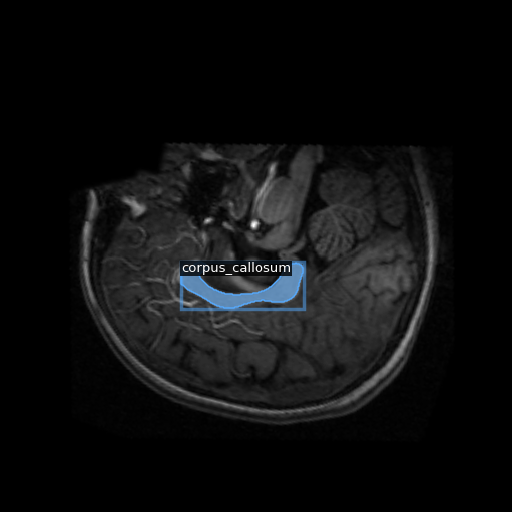

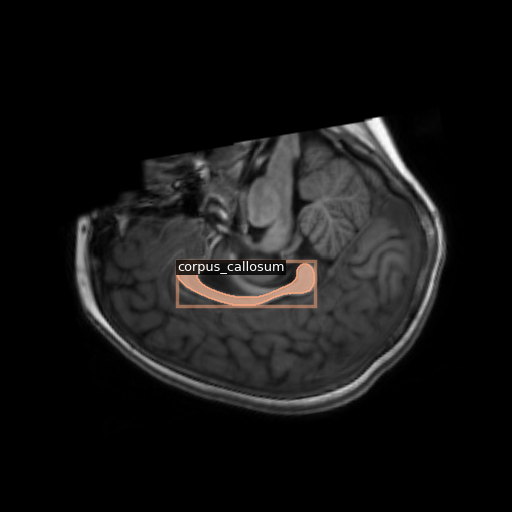

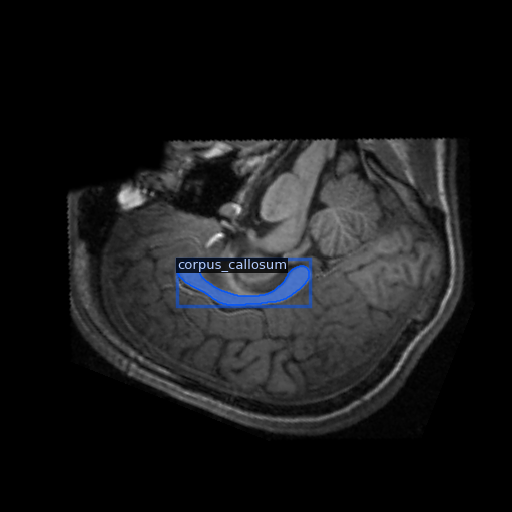

In [7]:
from detectron2.utils.visualizer import Visualizer
from google.colab.patches import cv2_imshow

dataset_dicts = get_cc_dicts(IMG_DIR, MSK_DIR, train_images)
for d in random.sample(dataset_dicts, 3):
    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=MetadataCatalog.get("cc_train"), scale=1.0)
    out = visualizer.draw_dataset_dict(d)
    cv2_imshow(out.get_image()[:, :, ::-1])

In [8]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
# Mask R-CNN ResNet-50 FPN mimarisini seçiyoruz (Hızlı ve dengeli)
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("cc_train",)
cfg.DATASETS.TEST = () # Eğitim sırasında test yapmıyoruz (hız için)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH = 2  # GPU belleğine göre 2-4 yapılabilir
cfg.SOLVER.BASE_LR = 0.00025  # Küçük bir öğrenme oranı medikal veride iyidir
cfg.SOLVER.MAX_ITER = 1500    # 1100 resim için 1500 iterasyon yeterli olacaktır
cfg.SOLVER.STEPS = []        # LR'yi düşürme adımları (gerek yok şu an)
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # Sadece Corpus Callosum

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)

print("Eğitim başlıyor...")
trainer.train()

[04/01 08:41:36 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:00, 198MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


Eğitim başlıyor...
[04/01 08:41:48 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0401 08:41:51.702000 2009 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[04/01 08:41:58 d2.utils.events]:  eta: 0:07:41  iter: 19  total_loss: 1.779  loss_cls: 0.8133  loss_box_reg: 0.261  loss_mask: 0.6938  loss_rpn_cls: 0.0266  loss_rpn_loc: 0.004418    time: 0.3202  last_time: 0.3423  data_time: 0.0160  last_data_time: 0.0126   lr: 4.9953e-06  max_mem: 1770M
[04/01 08:42:12 d2.utils.events]:  eta: 0:07:31  iter: 39  total_loss: 1.682  loss_cls: 0.6839  loss_box_reg: 0.3027  loss_mask: 0.6903  loss_rpn_cls: 0.01775  loss_rpn_loc: 0.004751    time: 0.3145  last_time: 0.2763  data_time: 0.0073  last_data_time: 0.0058   lr: 9.9902e-06  max_mem: 1773M
[04/01 08:42:19 d2.utils.events]:  eta: 0:07:34  iter: 59  total_loss: 1.52  loss_cls: 0.4983  loss_box_reg: 0.3221  loss_mask: 0.6806  loss_rpn_cls: 0.01864  loss_rpn_loc: 0.004865    time: 0.3187  last_time: 0.3012  data_time: 0.0087  last_data_time: 0.0073   lr: 1.4985e-05  max_mem: 1773M
[04/01 08:42:25 d2.utils.events]:  eta: 0:07:22  iter: 79  total_loss: 1.416  loss_cls: 0.3768  loss_box_reg: 0.3345  los

[04/01 09:17:53 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...
Model hiç görmediği veriler üzerinde test ediliyor...

Test Edilen Dosya: 0051185.png


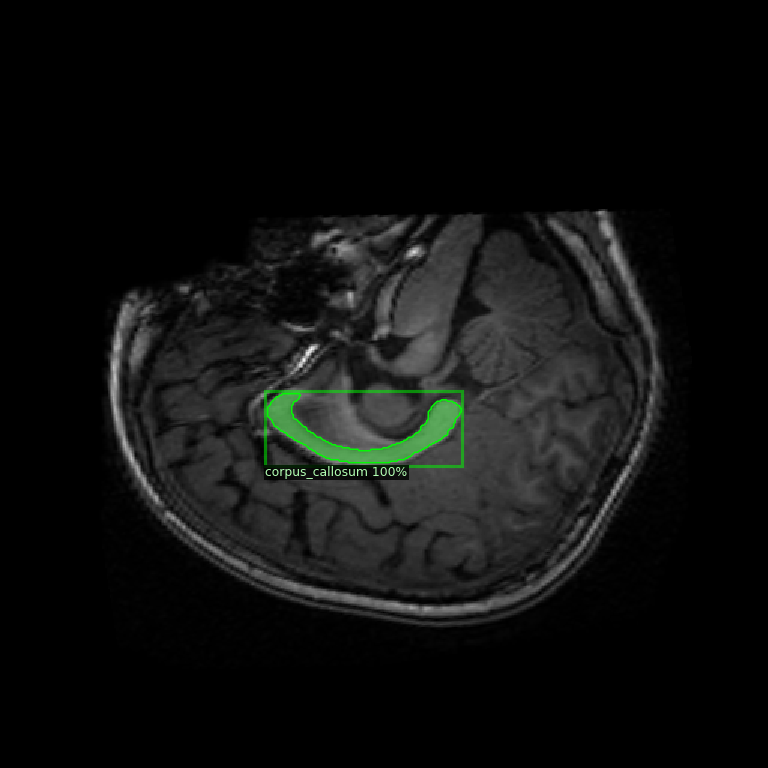

Test Edilen Dosya: 0050186.png


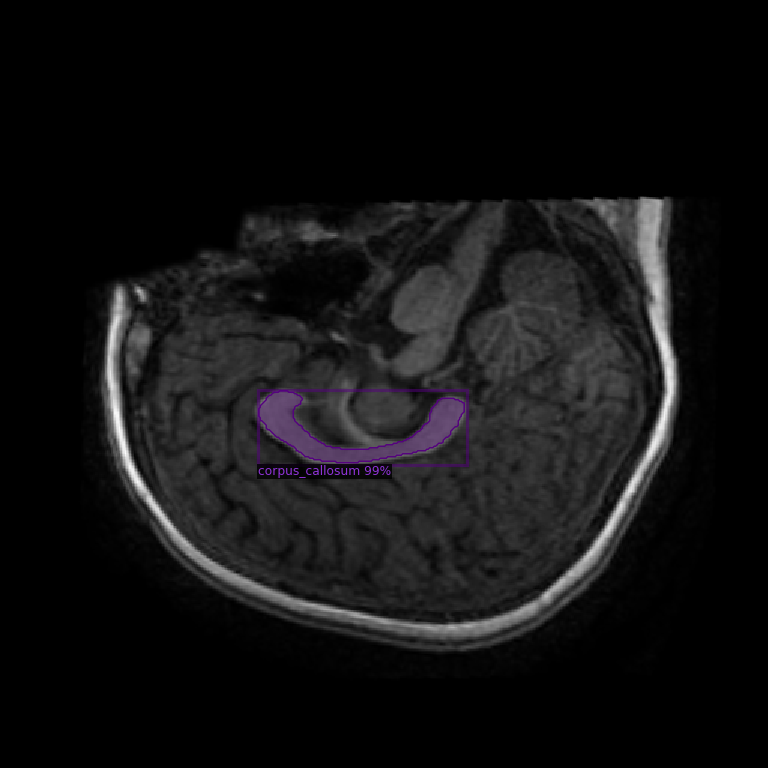

Test Edilen Dosya: 0050004.png


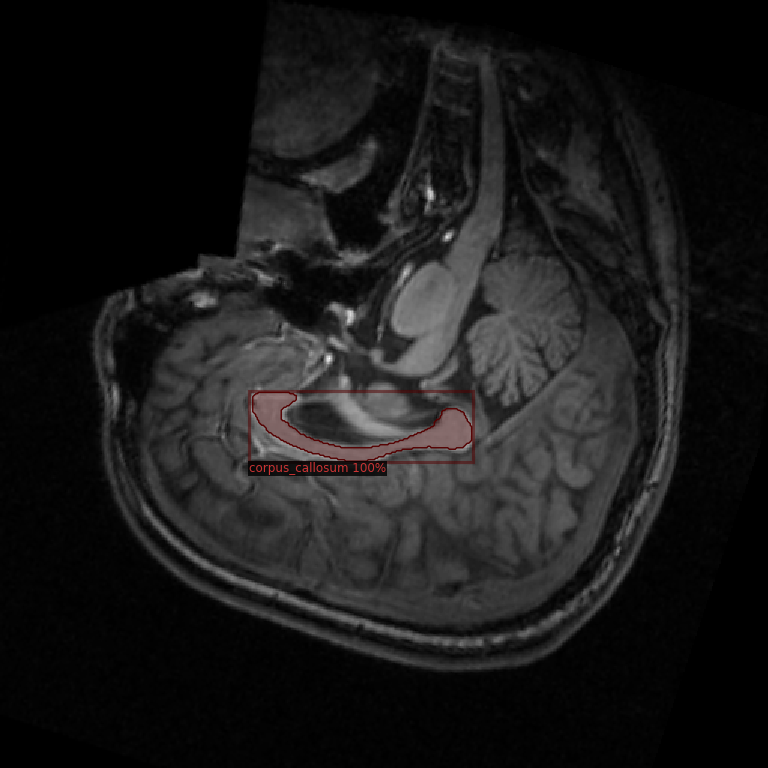

In [11]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.utils.visualizer import ColorMode

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.75
predictor = DefaultPredictor(cfg)

dataset_val_metadata = MetadataCatalog.get("cc_val")
IMG_DIR = "/content/OUT/IMG"

print("Model hiç görmediği veriler üzerinde test ediliyor...\n")

for img_name in random.sample(val_images, 3):
    img_path = os.path.join(IMG_DIR, img_name)
    im = cv2.imread(img_path)

    outputs = predictor(im)

    v = Visualizer(im[:, :, ::-1],
                   metadata=dataset_val_metadata,
                   scale=1.5,
                   instance_mode=ColorMode.IMAGE_BW
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    print(f"Test Edilen Dosya: {img_name}")
    cv2_imshow(out.get_image()[:, :, ::-1])

In [12]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# COCO Değerlendiricisini (Evaluator)
evaluator = COCOEvaluator("cc_val", output_dir="./output")

# Test veri seti (200)
val_loader = build_detection_test_loader(cfg, "cc_val")

print("Model sınava giriyor, lütfen bekleyin...\n")

sonuclar = inference_on_dataset(predictor.model, val_loader, evaluator)

print("\n--- SINAV SONUÇLARI ---")
print(sonuclar)

[04/01 09:18:45 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[04/01 09:18:45 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[04/01 09:18:45 d2.data.common]: Serializing 220 elements to byte tensors and concatenating them all ...
[04/01 09:18:45 d2.data.common]: Serialized dataset takes 0.24 MiB
Model sınava giriyor, lütfen bekleyin...

[04/01 09:18:45 d2.evaluation.evaluator]: Start inference on 220 batches
[04/01 09:18:46 d2.evaluation.evaluator]: Inference done 11/220. Dataloading: 0.0013 s/iter. Inference: 0.0796 s/iter. Eval: 0.0010 s/iter. Total: 0.0819 s/iter. ETA=0:00:17
[04/01 09:18:51 d2.evaluation.evaluator]: Inference done 73/220. Dataloading: 0.0016 s/iter. Inference: 0.0789 s/iter. Eval: 0.0009 s/iter. Total: 0.0815 s/iter. ETA=0:00:11
[04/01 09:18:56 d2.evaluation.evaluator]: Inference done 131/220. Da